In [1]:
import sys
from cpazmal_classification import *


In [156]:
_DEFAULT_HDF5 = str(
    Path("/home/mgallet/Documents/Codes/Python/1_DONE"
         "/CPAZMAL/DATASET/dataset_original/PAZTSX_CRYO_ML.hdf5")
)




# ── 1. Load HDF5 ─────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("CPAZMaL — Weibull WaSPS-DTW Classification")
print(f"{'='*70}")

hdf5 = Path(_DEFAULT_HDF5)
if not hdf5.exists():
    print(f"HDF5 not found at {hdf5} — downloading from HuggingFace…")
    from dataloader import download_cpazmal
    hdf5 = Path(download_cpazmal(str(hdf5.parent)))

loader = MLDatasetLoader(str(hdf5))



# ── 2. Extract time series ────────────────────────────────────────────────
print("\n[1/4] Extracting time series…")
dataset = extract_time_series(
    loader=loader,
    window_size=48,
    max_mask_value=2,
    max_mask_percentage=0.5,
    min_valid_percentage=0.999,
    orbit="DSC",
    polarization="HH",
    train_start="20200101",
    train_end="20211231",
    predict_start="20220101",
    predict_end="20221231",
    # scale_type="intensity",
    skip_optim_offset=True,
    verbose=True,
)
X_raw        = dataset['X_train']
y            = dataset['y']
idx_to_class = dataset['class_names']

T_series = X_raw[0].shape[0]
W_sq     = X_raw[0].shape[1]
print(f"  Loaded {len(X_raw)} samples, {len(np.unique(y))} classes, "
        f"T={T_series}, W²={W_sq}")

# Exclude user-specified classes (e.g. HAG, ICA with very few samples)
# if 'HAG,ICA':
#     exclude_names = {c.strip() for c in 'HAG,ICA'.split(',') if c.strip()}
#     name_to_label = {v: k for k, v in idx_to_class.items()}
#     exclude_labels = {name_to_label[n] for n in exclude_names if n in name_to_label}
#     if exclude_labels:
#         keep = np.array([y[i] not in exclude_labels for i in range(len(X_raw))])
#         X_raw        = [X_raw[i] for i in range(len(X_raw)) if keep[i]]
#         y            = y[keep]
#         idx_to_class = {k: v for k, v in idx_to_class.items() if k not in exclude_labels}
#         print(f"  After excluding {exclude_names}: {len(X_raw)} samples, "
#                 f"{len(np.unique(y))} classes")



CPAZMaL — Weibull WaSPS-DTW Classification

[1/4] Extracting time series…

CPAZMaL: Time Series Extraction (for WaSPS-DTW classification)
  Window:      48×48
  Orbit:       DSC  |  Polarisation: HH
  Train:       20200101 – 20211231
  Predict:     20220101 – 20221231
  Scale type:  amplitude
  Mask max:    ≤2 (0.5%)



Groups:   0%|          | 0/68 [00:00<?, ?grp/s, ABL001 (ABL)]/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/src/dataloader/cpazmal_loader.py:351: RuntimeWarning: invalid value encountered in sqrt
  images = np.where(images >= 0, np.sqrt(images), np.nan).astype(np.float32)
Groups: 100%|██████████| 68/68 [00:30<00:00,  2.25grp/s, ROC009 (ROC)]


Extraction complete:
  Total samples (windows):  579
  X_train[0].shape:         (56, 2304)  (T_train, W²)
  X_predict[0].shape:       (10, 2304)  (T_predict, W²)
    Class  0 (ACC            ): 105 samples
    Class  1 (PLA            ): 55 samples
    Class  2 (ROC            ): 74 samples
    Class  4 (ABL            ): 100 samples
    Class  5 (ICA            ): 4 samples
    Class  6 (LAC            ): 5 samples
    Class  7 (FOR            ): 236 samples
  Loaded 579 samples, 7 classes, T=56, W²=2304


In [160]:

if 'HAG':
    exclude_names = {c.strip() for c in 'HAG'.split(',') if c.strip()}
    name_to_label = {v: k for k, v in idx_to_class.items()}
    exclude_labels = {name_to_label[n] for n in exclude_names if n in name_to_label}
    if exclude_labels:
        keep = np.array([y[i] not in exclude_labels for i in range(len(X_raw))])
        X_raw        = [X_raw[i]**2 for i in range(len(X_raw)) if keep[i]]
        y            = y[keep]
        idx_to_class = {k: v for k, v in idx_to_class.items() if k not in exclude_labels}
        print(f"  After excluding {exclude_names}: {len(X_raw)} samples, "
                f"{len(np.unique(y))} classes")


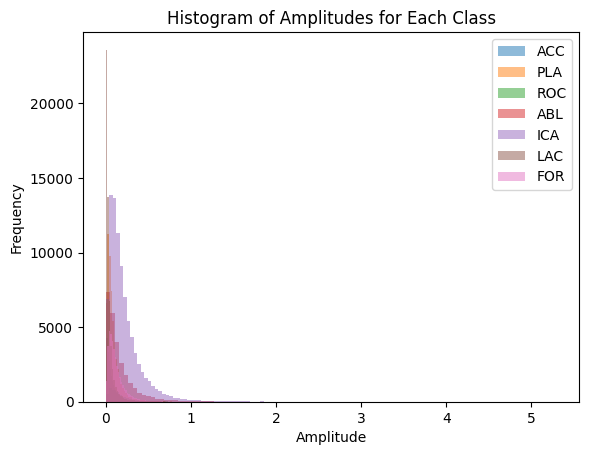

In [163]:
import matplotlib.pyplot as plt
for name, label in name_to_label.items():
    try:
        idx_acc = np.where(y == label)[0]
        plt.hist(np.array(X_raw)[idx_acc][0,np.isfinite(np.array(X_raw)[idx_acc][0])].flatten()**2, bins=100, alpha=0.5, label=name)
    except Exception as e:
        print(f"Error processing class '{name}': {e}")
plt.xlabel('Amplitude')
plt.ylabel('Frequency')
plt.title('Histogram of Amplitudes for Each Class')
plt.legend()
plt.show()

In [164]:

from src.experiments.cpazmal_classification import _estimate_weibull_list
t0 = time.time()
# clean_raw = [x for x in X_raw if np.isfinite(x)]
# drop all non-finite values (NaN, inf) for Weibull fitting
clean_raw = []
import tqdm
for x in tqdm.tqdm(X_raw[:]):
    temp_vals = []
    for val in range(x.shape[0]):
        temp = x[val][np.isfinite(x[val])]
        temp = temp[temp>0]  # Keep only positive values for Weibull fitting
        temp = temp - (np.min(temp) + 1e-8)  # Shift to ensure all values are > 0   
        temp = temp[temp>0]  # Keep only positive values for Weibull fitting
        temp_vals.append(temp**2)
    clean_raw.append(temp_vals)


# clean_raw = [x-np.min(clean_raw) + 1e-8 for x in clean_raw]  # Shift to ensure all values are > 0
X_params = np.array(_estimate_weibull_list(clean_raw))

print(f"  Done in {time.time()-t0:.1f}s — shape: {X_params[0].shape} (T, 2) = (k, λ)")

100%|██████████| 579/579 [00:00<00:00, 733.13it/s]


  Done in 1.7s — shape: (56, 2) (T, 2) = (k, λ)


In [ ]:
plt

In [127]:
from scipy.stats import weibull_min

def Weibull_MLE(data):
    """
    Estime (mu, eta) par maximum de vraisemblance (scipy),
    cohérent avec Weibull_pdf(x, mu, eta) :
        f(x) = (eta/mu) * (x/mu)^(eta-1) * exp(-(x/mu)^eta)

    mu  = paramètre d'échelle (scale)
    eta = paramètre de forme (shape)

    Parameters
    ----------
    data : array-like, valeurs > 0

    Returns
    -------
    mu, eta : tuple de floats
    """
    eta, _, mu = weibull_min.fit(data[np.isfinite(data) & (data > 0)], floc=0)
    return mu, eta

In [148]:
import numpy as np
from scipy.optimize import newton

def _g(k, x, logx, mean_logx):
    xk = x ** k
    return np.sum(xk * logx) / np.sum(xk) - mean_logx - 1.0 / k

def _g_prime(k, x, logx, mean_logx):
    xk = x ** k
    xklogx = xk * logx
    A  = np.sum(xklogx)
    A2 = np.sum(xklogx * logx)
    B  = np.sum(xk)
    return (A2 * B - A * A) / (B * B) + 1.0 / (k * k)

def Weibull_MLE_fast(data):
    """
    MLE rapide du Weibull (loc=0), via résolution 1D (Newton) sur k,
    avec lambda en forme fermée. Convention de sortie : (mu, eta)
    cohérente avec Weibull_pdf(x, mu, eta).
    """
    x = np.asarray(data, dtype=float)
    logx = np.log(x)
    mean_logx = np.mean(logx)

    # point de départ = estimation log-cumulants (corrigée)
    k0, _ = estimate_weibull_fast(data)

    k_hat = newton(_g, k0, fprime=_g_prime,
                    args=(x, logx, mean_logx),
                    tol=1e-8, maxiter=5)

    lam_hat = (np.mean(x ** k_hat)) ** (1.0 / k_hat)

    eta = k_hat
    mu  = lam_hat
    return mu, eta

In [149]:
(clean_raw[120][20]>0).sum()/len(clean_raw[120][20])

1.0

In [150]:
estimate_weibull_fast(clean_raw[120][20]), Weibull_MLE(clean_raw[120][20]), Weibull_MLE_fast(clean_raw[120][20])

((2.371729889915994, 0.1905347844653575),
 (0.19298551790860347, 2.0728256565575007),
 (0.1929835973671507, 2.072823803455132))

In [151]:
# %timeit estimate_weibull_fast(clean_raw[0][0])
# %timeit Weibull_MLE(clean_raw[0][0])
%timeit Weibull_MLE_fast(clean_raw[0][0])

1.27 ms ± 2.19 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [173]:

def estimate_exponential_fast(data):
    """
    Fast exponential parameter estimation.
    
    Parameters
    ----------
    data : array of double
        Input samples
        
    Returns
    -------
    lambda_param : double
        Estimated rate parameter
    """
    # k1 = compute_log_mean(data)
    k1 = np.mean(np.log(data[np.isfinite(data) & (data > 0)]))  # Ensure we only take the mean of finite, positive values
    DIGAMMA_1 = 0.57721566490153286060  # Euler-Mascheroni constant
    lambda_param =  np.exp(k1 - DIGAMMA_1)  # Corrected formula for lambda estimation
    
    return lambda_param


In [188]:
%pip install "numpy>=2.0"


  Using cached numpy-2.4.6-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.63.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [187]:
import jax
import jax.numpy as jnp
from jax import jit, vmap

PI2_6 = jnp.pi**2 / 6.0

def _g_and_gprime(k, x, logx, mean_logx):
    xk = x ** k
    A  = jnp.sum(xk * logx)
    A2 = jnp.sum(xk * logx * logx)
    B  = jnp.sum(xk)
    g  = A / B - mean_logx - 1.0 / k
    gp = (A2 * B - A * A) / (B * B) + 1.0 / (k * k)
    return g, gp

@jit
def weibull_mle_jax(x, n_iter=6):
    logx = jnp.log(x)
    mean_logx = jnp.mean(logx)
    log_var = jnp.var(logx)
    k0 = jnp.sqrt(PI2_6 / log_var)  # init par log-cumulants

    def body(_, k):
        g, gp = _g_and_gprime(k, x, logx, mean_logx)
        return k - g / gp

    k_hat = jax.lax.fori_loop(0, n_iter, body, k0)
    lam_hat = jnp.mean(x ** k_hat) ** (1.0 / k_hat)
    return lam_hat, k_hat  # (mu, eta)

# --- batch sur N fenêtres de même taille ---
batched_mle = jit(vmap(weibull_mle_jax, in_axes=0))

# data_batch : array de forme (n_windows, window_size)
mu_arr, eta_arr = batched_mle(clean_raw_selected)

AttributeError: module 'numpy.dtypes' has no attribute 'StringDType'

In [174]:
lambd = estimate_exponential_fast(clean_raw_selected)
from scipy.stats import expon
lambd2=expon.fit(clean_raw_selected, floc=0)[1]  # Fix location to 0 for better fitting
lambd2, lambd

(0.02351426807245925, 0.007097020726819991)

Estimated Weibull parameters (fast): k=1.20, λ=0.06
Estimated Weibull parameters (scipy): k=0.95, loc=0.00, scale=0.01
Estimated Gamma parameters (scipy): k=0.21, loc=0.00, scale=1.97
Estimated Gumbel parameters (scipy): k=-0.59, loc=0.01, scale=0.01


Text(0.5, 1.0, 'Weibull Fit to Amplitude Distribution')

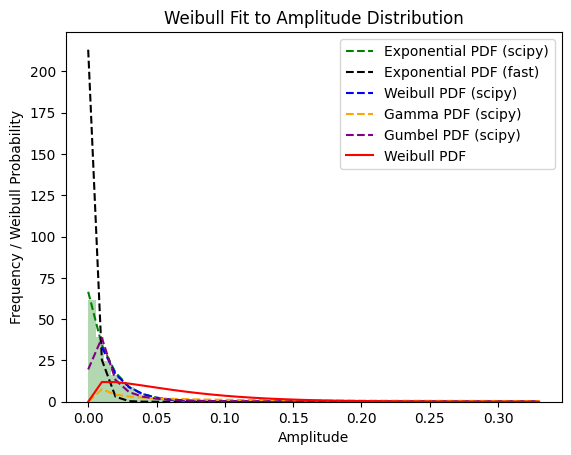

In [180]:

idx = 124

clean_raw_selected = clean_raw[idx][10]
# X_raw[idx][10][np.isfinite(X_raw[idx][10])]
# clean_raw[idx][0]
plt.hist(clean_raw_selected, bins=40, density=True, alpha=0.3, color='g')
    # X_raw[idx][0,:], bins=25, density=True, alpha=0.6, color='g')
y_weibull = np.arange(0,1.5*np.nanmax(clean_raw_selected), 0.01)  # Adjust range based on data
def Weibull_pdf(x, *args):
    if len(args) == 2:
       eta,mu = args
    else:
        raise ValueError("Weibull_pdf takes 2 arguments")
    return (eta / mu) * ((x / mu) ** (eta - 1)) * np.exp(-((x / mu) ** eta))


lambd = estimate_exponential_fast(clean_raw_selected)
from scipy.stats import expon
lambd2=expon.fit(clean_raw_selected, floc=0)[1]  # Fix location to 0 for better fitting

plt.plot(y_weibull, expon.pdf(y_weibull, loc=0, scale=lambd2), label='Exponential PDF (scipy)', color='green', linestyle='dashed')
plt.plot(y_weibull, expon.pdf(y_weibull, loc=0, scale=lambd), label='Exponential PDF (fast)', color='black', linestyle='dashed')

pdf_weibull = Weibull_pdf(y_weibull, *X_params[idx][0])
k_scipy, loc_scipy, scale_scipy = weibull_min.fit(clean_raw_selected, floc=0)  # Fix location to 0 for better fitting
pdf_weibull_scipy = weibull_min.pdf(y_weibull, k_scipy, loc=0, scale=scale_scipy)
plt.plot(y_weibull, pdf_weibull_scipy, label='Weibull PDF (scipy)', color='blue', linestyle='dashed')

# plt.plot(y_weibull, pdf_weibull, label='Weibull PDF', color='red')

# estimate Weibull with scipy.stats
from scipy.stats import weibull_min,gamma,genextreme
gamma_k, gamma_loc, gamma_scale = gamma.fit(clean_raw_selected)
genextreme_k, genextreme_loc, genextreme_scale = genextreme.fit(clean_raw_selected)
print(f"Estimated Weibull parameters (fast): k={X_params[idx][0][0]:.2f}, λ={X_params[idx][0][1]:.2f}")
print(f"Estimated Weibull parameters (scipy): k={k_scipy:.2f}, loc={loc_scipy:.2f}, scale={scale_scipy:.2f}")
print(f"Estimated Gamma parameters (scipy): k={gamma_k:.2f}, loc={gamma_loc:.2f}, scale={gamma_scale:.2f}")
print(f"Estimated Gumbel parameters (scipy): k={genextreme_k:.2f}, loc={genextreme_loc:.2f}, scale={genextreme_scale:.2f}")
pdf_gamma_scipy = gamma.pdf(y_weibull, gamma_k, loc=gamma_loc, scale=gamma_scale)
plt.plot(y_weibull, pdf_gamma_scipy, label='Gamma PDF (scipy)', color='orange', linestyle='dashed')
pdf_genextreme_scipy = genextreme.pdf(y_weibull, genextreme_k, loc=genextreme_loc, scale=genextreme_scale)  
plt.plot(y_weibull, pdf_genextreme_scipy, label='Gumbel PDF (scipy)', color='purple', linestyle='dashed')
plt.plot(y_weibull, pdf_weibull, label='Weibull PDF', color='red')
plt.xlabel('Amplitude')
plt.ylabel('Frequency / Weibull Probability')
plt.legend()
plt.title('Weibull Fit to Amplitude Distribution')

In [ ]:
seed = 452
# ── 4. Train / test split ─────────────────────────────────────────────────
idx_all = np.arange(len(X_raw))
tr_idx, te_idx = train_test_split(
    idx_all, test_size=0.2, stratify=y, random_state=seed)

X_raw_train    = [X_raw[i]    for i in tr_idx]
X_raw_test     = [X_raw[i]    for i in te_idx]
X_params_train = [X_params[i] for i in tr_idx]
X_params_test  = [X_params[i] for i in te_idx]
y_train, y_test = y[tr_idx], y[te_idx]
print(f"  Train: {len(y_train)}  Test: {len(y_test)}")

# Balance training set only — test distribution stays as the natural imbalance
X_raw_train, X_params_train, y_train = balance_dataset(
    X_raw_train, X_params_train, y_train,
    mode="subsample",
    seed=seed,
)
classes_after, counts_after = np.unique(y_train, return_counts=True)
print(f"  After {args.balance_mode}: {len(y_train)} training samples")
for c, n in zip(classes_after, counts_after):
    print(f"    {idx_to_class[c]}: {n}")

# Write dataset log after split + balance so it reflects the actual training data used
classes_raw = sorted(np.unique(y))
log = {
    'hdf5_path': str(hdf5),
    'extraction_params': {
        'window_size':       args.window_size,
        'orbit':             args.orbit,
        'polarization':      args.polarization,
        'train_start':       args.train_start,
        'train_end':         args.train_end,
        'predict_start':     args.predict_start,
        'predict_end':       args.predict_end,
        'scale_type':        args.scale_type,
        'skip_optim_offset': False,
    },
    'n_total_samples': len(X_raw),
    'T':    T_series,
    'W_sq': W_sq,
    'excluded_classes': args.exclude_classes,
    'balance_mode': args.balance_mode,
    'max_samples_per_class': args.max_samples_per_class,
    'classes_raw': {
        idx_to_class[int(cls)]: {
            'label':     int(cls),
            'n_samples': int(np.sum(y == cls)),
        }
        for cls in classes_raw
    },
    'train_balanced': {
        idx_to_class[int(cls)]: int(np.sum(y_train == cls))
        for cls in sorted(np.unique(y_train))
    },
    'test_distribution': {
        idx_to_class[int(cls)]: int(np.sum(y_test == cls))
        for cls in sorted(np.unique(y_test))
    },
    'n_train': int(len(y_train)),
    'n_test':  int(len(y_test)),
    'timestamp': datetime.now().isoformat(),
}
log_path = out_dir / 'dataset_log.json'
with open(log_path, 'w') as f:
    json.dump(log, f, indent=2)
print(f"  Dataset log: {log_path}")

# ── 5. Classification ─────────────────────────────────────────────────────
print("\n[3/4] Running classification…")
results = {}

if args.mode == 'compare':
    results = run_compare(
        X_raw_train, X_raw_test,
        X_params_train, X_params_test,
        y_train, y_test,
        gamma=args.gamma, sgd_epochs=args.sgd_epochs, sgd_lr=args.sgd_lr,
        idx_to_class=idx_to_class, verbose=args.verbose,
    )

    # Persist experiment data for downstream analysis / sensitivity scripts
    pkl_path = out_dir / 'experiment_data.pkl'
    X_raw_train_clean = _clean_raw(X_raw_train)
    with open(pkl_path, 'wb') as _f:
        pickle.dump({
            'results':          results,
            'X_raw_train_clean': X_raw_train_clean,
            'X_params_train':   X_params_train,
            'X_params_test':    X_params_test,
            'X_raw_test_clean': _clean_raw(X_raw_test),
            'y_train':          y_train,
            'y_test':           y_test,
            'idx_to_class':     idx_to_class,
        }, _f)
    print(f"  Experiment data saved: {pkl_path}")

    # Confusion matrices and barycenter plots
    from plot.classification_plots import (
        plot_confusion_matrices,
        plot_barycenter_with_samples,
    )
    plot_confusion_matrices(results, y_test, idx_to_class, str(out_dir))
    print(f"  Confusion matrices saved.")

    plot_barycenter_with_samples(
        results, X_raw_train_clean, X_params_train, y_train, idx_to_class,
        output_dir=str(out_dir),
        param_names=['k (shape)', 'λ (scale)'],
        log_scale=False,
    )
    print(f"  Barycenter plots saved.")

    # Multi-gamma barycenter comparison plots
    if args.plot_gammas:
        from plot.classification_plots import plot_barycenters_gamma_comparison
        gammas_plot = [float(g) for g in args.plot_gammas.split(',')]
        barycenters_by_gamma = {}
        for g in gammas_plot:
            print(f"\n  Computing barycenters at γ={g} for comparison plot…")
            barycenters_by_gamma[g] = compute_barycenters_all_methods(
                X_raw_train_clean, X_params_train, y_train,
                gamma=g, sgd_epochs=args.sgd_epochs, sgd_lr=args.sgd_lr,
            )
        plot_barycenters_gamma_comparison(
            barycenters_by_gamma, idx_to_class,
            output_dir=str(out_dir),
            param_names=['k (shape)', 'λ (scale)'],
        )
        print(f"  Multi-gamma barycenter plots saved.")

if args.mode in ('kmedoid', 'both'):
    results['kmedoid'] = run_kmedoid(
        X_params_train, X_params_test, y_train, y_test,
        gamma=args.gamma, sgd_epochs=args.sgd_epochs, sgd_lr=args.sgd_lr,
        idx_to_class=idx_to_class, verbose=args.verbose,
    )

if args.mode in ('shapelet', 'both'):
    results['shapelet'] = run_shapelets(
        X_params_train, X_params_test, y_train, y_test,
        gamma=args.gamma, epochs=args.epochs,
        batch_size=args.batch_size, lr=args.lr,
        num_shapelets_per_scale=args.num_shapelets,
        idx_to_class=idx_to_class, verbose=args.verbose,
        seed=args.seed,
    )

# ── 6. Save results ───────────────────────────────────────────────────────
print(f"\n[4/4] Saving results to {out_dir}/")
rows = [
    {'method':           r['method'],
        'f1_weighted':      r['f1_weighted'],
        'f1_macro':         r['f1_macro'],
        'barycenter_time':  r['barycenter_time'],
        'classify_time':    r['classify_time']}
    for r in results.values()
]
df = pd.DataFrame(rows)
csv_path = out_dir / "classification_scores.csv"
df.to_csv(csv_path, index=False)
print(df.to_string(index=False))
print(f"\nSaved: {csv_path}")


if __name__ == '__main__':
main()
